In [1]:
# imports
from dataset_utils import *
from matplotlib import pyplot as plt
import statistics

In [2]:
def eval_dataset(dataset_loader):
    """
    prints some metrics about the provided dataset
    :param dataset_loader: the dataset to analyze
    """
    tweet_counts = {}
    user_counts = {}

    for i, sample in enumerate(dataset_loader):
        label = sample.label
        tweet_count = len(sample.tweet_data)

        if not label in list(tweet_counts.keys()):
            tweet_counts[label] = []
            user_counts[label] = 0
        tweet_counts.get(label).append(tweet_count)
        user_counts[label] = 1 + user_counts.get(label)
        print(f"\rIteration: {i}", end="")
        #print(f"\rTweet count: {tweet_count}", end="")
    print("")
    print("----------")
    print("Amount of labeled users:")
    for key, value in user_counts.items():
        print(f"-- {key}: {value}")
    print("----------")
    print("[Tweet statistics per label]")
    for label, counts in tweet_counts.items():
        print(f"{label}:")
        print(f"-- Total Tweet Count:  {sum(counts)}")
        print(f"-- Mean: {statistics.mean(counts)}")
        print(f"-- Median: {statistics.median(counts)}")
        print(f"-- Standard Deviation: {statistics.stdev(counts)}")
        print(f"-- Min: {min(counts)}")
        print(f"-- Max: {max(counts)}")
    fig, ax = plt.subplots(1,len(tweet_counts.keys()), figsize=(20,5))
    for i,key in enumerate(list(tweet_counts.keys())):
        ax[i].hist(tweet_counts.get(key), bins=50)
        ax[i].set_title(f"Tweet Amount per user for {key}")

def preview_one_sample(dataset_loader, wanted_label):
    """
    previews one sample from the dataset for the specified label
    :param dataset_loader: the dataset to take a sample from
    :param wanted_label: the wanted sample type
    """
    sample = None
    for i, pick in enumerate(dataset_loader):
        if pick.label == wanted_label:
            sample = pick
            break

    print("----------")
    print("label: ", sample.label)
    print("user meta data: ", sample.user_data)
    print("----------")
    for i,tweet in enumerate(sample.tweet_data):
        print("tweet: ", tweet.text)
    print("----------")

Iteration: 10144
----------
Amount of labeled users:
-- human: 2563
-- fake_follower: 2348
-- social_spam1: 73
-- social_spam2: 2764
-- social_spam3: 356
-- traditional_spam1: 783
-- traditional_spam2: 24
-- traditional_spam3: 327
-- traditional_spam4: 907
----------
[Tweet statistics per label]
human:
-- Total Tweet Count:  2076573
-- Mean: 810.2118611002732
-- Median: 0
-- Standard Deviation: 1324.873801887839
-- Min: 0
-- Max: 3250
fake_follower:
-- Total Tweet Count:  111952
-- Mean: 47.67972742759795
-- Median: 23.0
-- Standard Deviation: 175.54831642505155
-- Min: 0
-- Max: 3383
social_spam1:
-- Total Tweet Count:  148537
-- Mean: 2034.7534246575342
-- Median: 1748
-- Standard Deviation: 506.1161697130939
-- Min: 1197
-- Max: 3232
social_spam2:
-- Total Tweet Count:  338937
-- Mean: 122.62554269175108
-- Median: 107.0
-- Standard Deviation: 184.91486771314587
-- Min: 38
-- Max: 3242
social_spam3:
-- Total Tweet Count:  1097675
-- Mean: 3083.3567415730336
-- Median: 3223.0
-- Stan

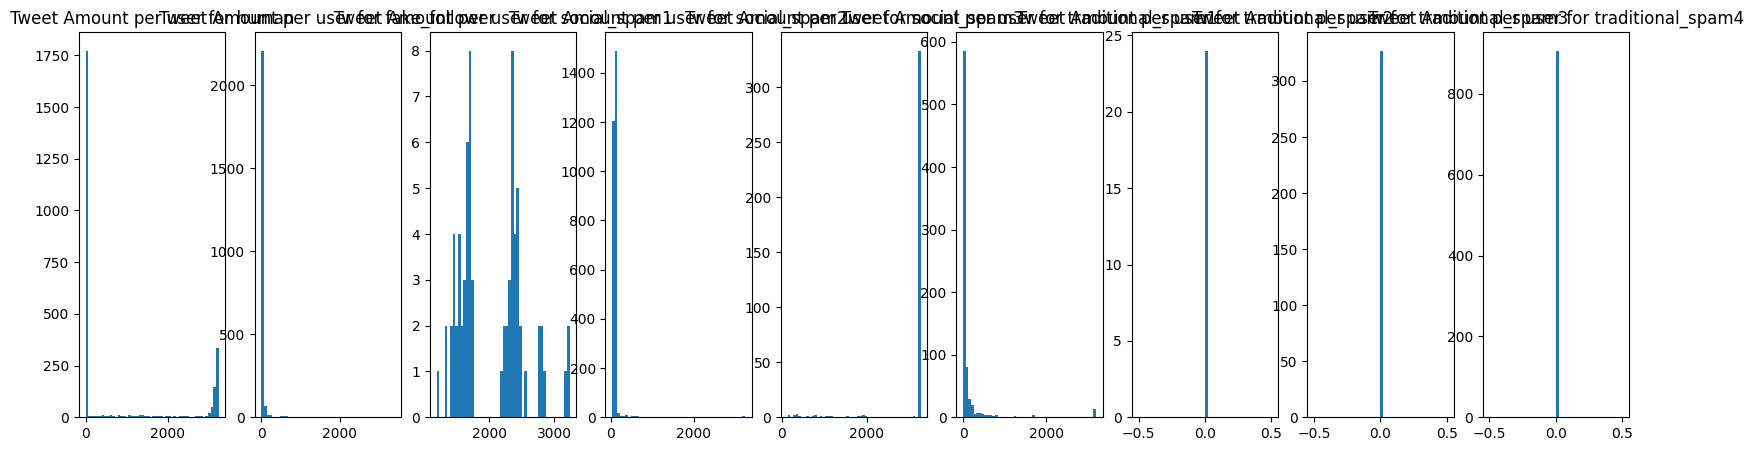

In [6]:
# Dataset: Cresci 17
dataset_mode = "train"
user_dataset = Cresci17(Cresci17SetTypes.GENUINE_USER, dataset_mode, root="./datasets", custom_label="human")
fake_dataset = Cresci17(Cresci17SetTypes.FAKE_FOLLOWER, dataset_mode, root="./datasets", custom_label="fake_follower")
social1_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_1, dataset_mode, root="./datasets", custom_label="social_spam1")
social2_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_2, dataset_mode, root="./datasets", custom_label="social_spam2")
social3_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_3, dataset_mode, root="./datasets", custom_label="social_spam3")
traditional1_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_1, dataset_mode, root="./datasets", custom_label="traditional_spam1")
traditional2_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_2, dataset_mode, root="./datasets", custom_label="traditional_spam2")
traditional3_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_3, dataset_mode, root="./datasets", custom_label="traditional_spam3")
traditional4_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_4, dataset_mode, root="./datasets", custom_label="traditional_spam4")
combo_dataset = InterleavedIterableDataset([user_dataset, fake_dataset, social1_dataset, social2_dataset, social3_dataset, traditional1_dataset, traditional2_dataset, traditional3_dataset, traditional4_dataset], "RoundRobin")

eval_dataset(combo_dataset)
#preview_one_sample(combo_dataset, "human")

Iteration: 20834
----------
Amount of labeled users:
-- human: 6004
-- bot: 14831
----------
[Tweet statistics per label]
human:
-- Total Tweet Count:  292774
-- Mean: 48.76315789473684
-- Median: 2.0
-- Standard Deviation: 725.5667005979391
-- Min: 1
-- Max: 45980
bot:
-- Total Tweet Count:  339776
-- Mean: 22.90985098779583
-- Median: 11
-- Standard Deviation: 140.94559824120745
-- Min: 1
-- Max: 10596


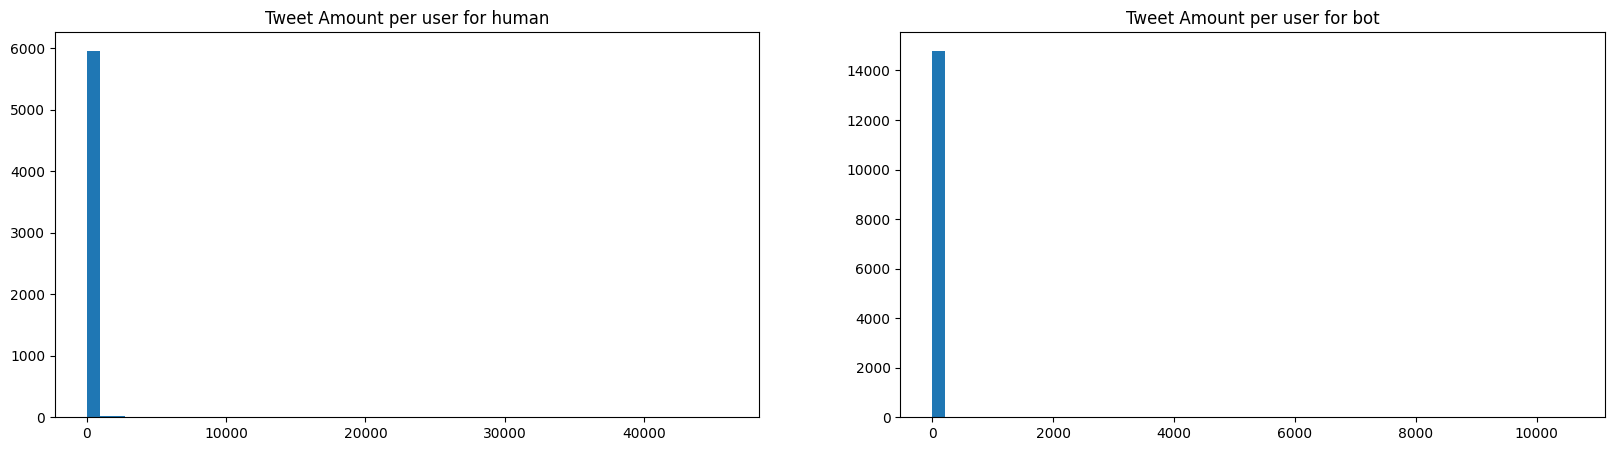

In [3]:
# Dataset: Cresci 18
dataset = Cresci18("train", root="./datasets", use_only_labelled=True, label_mapping=["bot","human","unlabelled"])
eval_dataset(dataset)
#preview_one_sample(dataset, "human")

Iteration: 31943
----------
Amount of labeled users:
-- bot: 16631
-- human: 15313
----------
[Tweet statistics per label]
bot:
-- Total Tweet Count:  1876996
-- Mean: 112.86128314593229
-- Median: 124
-- Standard Deviation: 82.28076794314909
-- Min: 1
-- Max: 200
human:
-- Total Tweet Count:  2586958
-- Mean: 168.9386795533207
-- Median: 200
-- Standard Deviation: 60.25952743391116
-- Min: 1
-- Max: 200


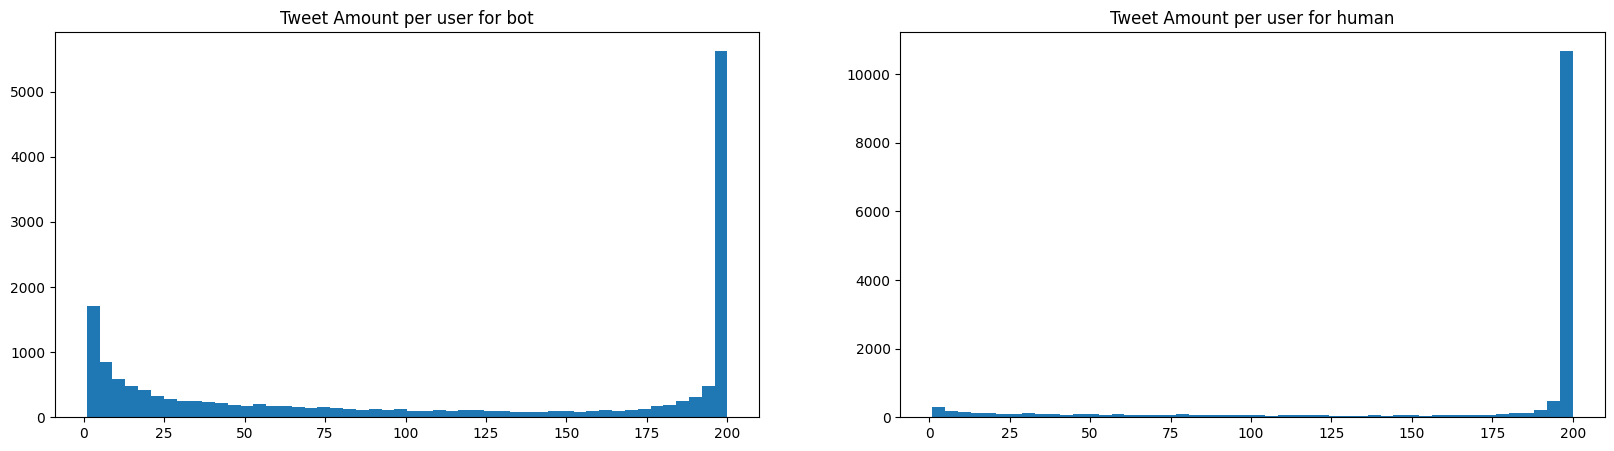

In [4]:
# Dataset: Caverlee 11
dataset = Caverlee11("train", root="./datasets", label_mapping=["bot","human"])
eval_dataset(dataset)
#preview_one_sample(dataset, "human")

Iteration: 9504
----------
Amount of labeled users:
-- bot: 5307
-- human: 4198
----------
[Tweet statistics per label]
bot:
-- Total Tweet Count:  864118
-- Mean: 162.82607876389673
-- Median: 199
-- Standard Deviation: 67.45737925228013
-- Min: 0
-- Max: 200
human:
-- Total Tweet Count:  741776
-- Mean: 176.69747498808957
-- Median: 200.0
-- Standard Deviation: 57.89149141275066
-- Min: 0
-- Max: 201


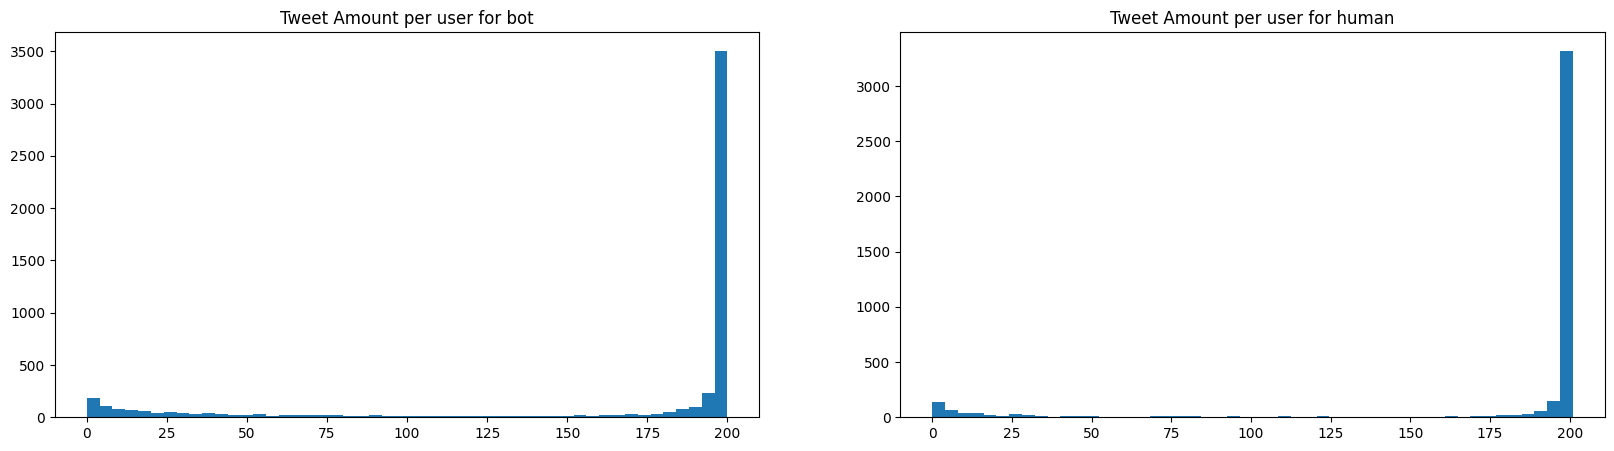

In [5]:
# Dataset: Twibot 20
dataset = Twibot20("train", root="./datasets", label_mapping=["bot", "human"])
eval_dataset(dataset)
#preview_one_sample(dataset, "human")

--> Loading labels...
--> Successfully cached 50000 users in memory.
--> Successfully cached 100000 users in memory.
--> Successfully cached 150000 users in memory.
--> Successfully cached 200000 users in memory.
--> Successfully cached 250000 users in memory.
--> Successfully cached 300000 users in memory.
--> Successfully cached 350000 users in memory.
--> Successfully cached 400000 users in memory.
--> Successfully cached 450000 users in memory.
--> Successfully cached 500000 users in memory.
--> Successfully cached 550000 users in memory.
--> Successfully cached 600000 users in memory.
--> Successfully cached 650000 users in memory.
--> Successfully cached 700000 users in memory.
--> Successfully cached 750000 users in memory.
--> Successfully cached 800000 users in memory.
--> Successfully cached 850000 users in memory.
--> Successfully cached 900000 users in memory.
--> Successfully cached 950000 users in memory.
--> Successfully cached 1000000 users in memory.
Iteration: 39999
-

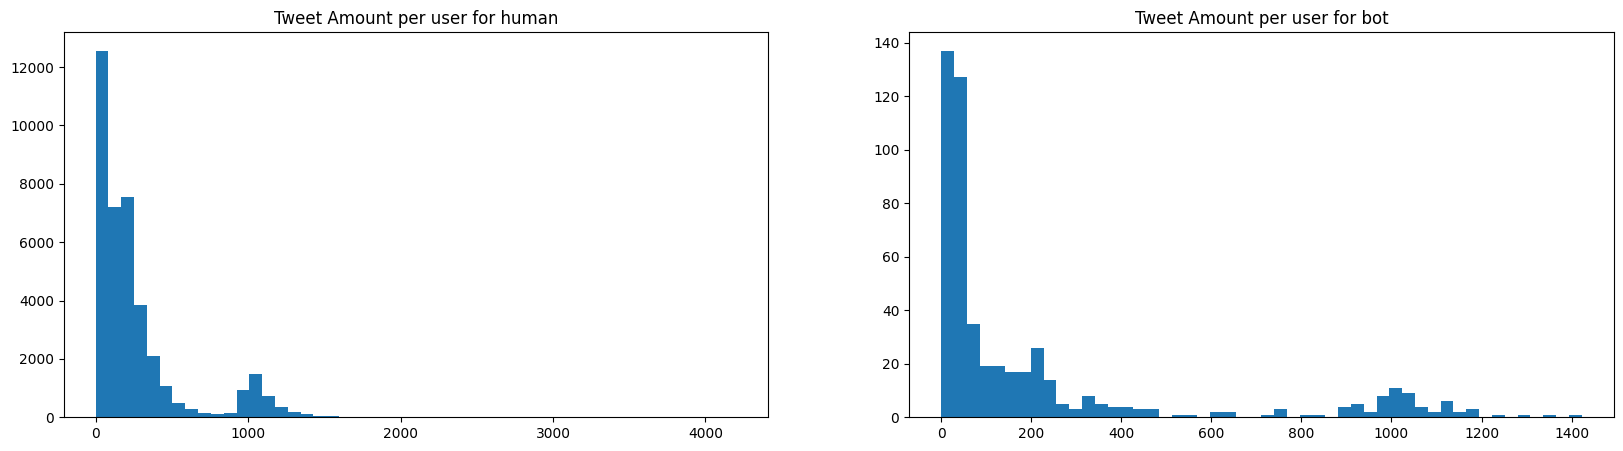

In [3]:
# Dataset: Twibot 22
dataset = Twibot22Improved("train", root="./datasets", label_mapping=["bot","human"], sub_sample_size=40000)
#dataset.prepare_dataset()
eval_dataset(dataset)
#preview_one_sample(dataset, "human")